Dataset shape: (150, 5)

Class distribution:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Logistic Regression
  Test accuracy      : 0.9333
  5-fold CV accuracy : 0.9600 (+/- 0.0389)

Decision Tree
  Test accuracy      : 0.9000
  5-fold CV accuracy : 0.9533 (+/- 0.0340)

Random Forest
  Test accuracy      : 0.9000
  5-fold CV accuracy : 0.9600 (+/- 0.0249)

KNN (k=5)
  Test accuracy      : 0.9333
  5-fold CV accuracy : 0.9600 (+/- 0.0249)

SVM (RBF kernel)
  Test accuracy      : 0.9667
  5-fold CV accuracy : 0.9667 (+/- 0.0211)

Best model: SVM (RBF kernel)

Classification report (test set):

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30

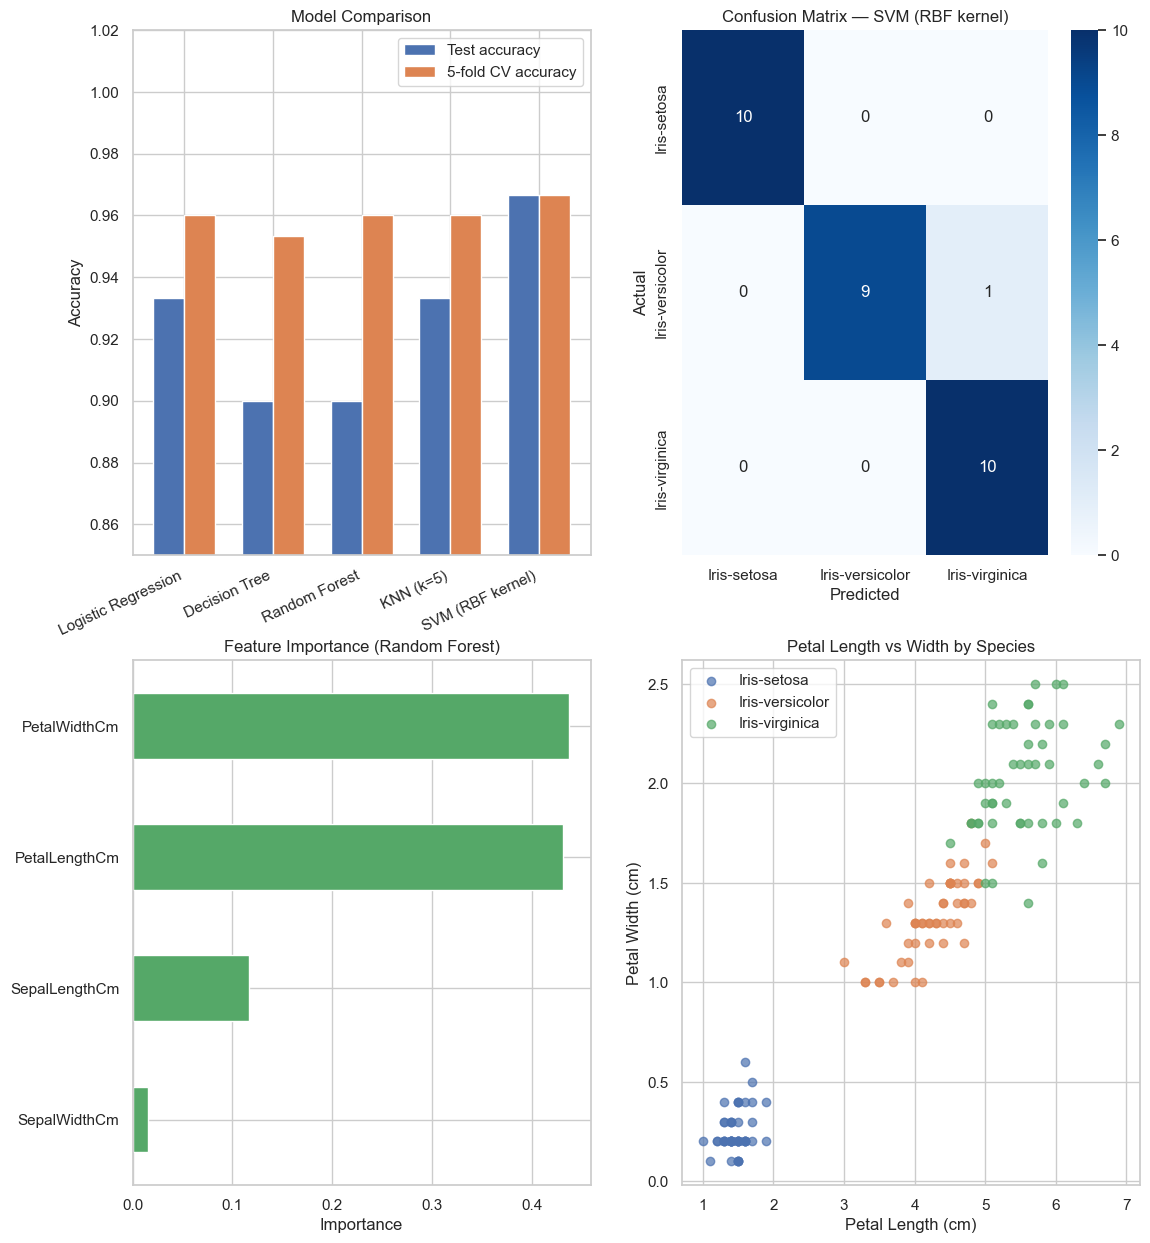

In [12]:
"""
Iris Flower Classification
---------------------------
Trains and evaluates ML models to classify Iris flowers (setosa, versicolor,
virginica) from sepal/petal measurements.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

RANDOM_STATE = 42


# 1. Load data

df = pd.read_csv("Iris.csv")
df = df.drop(columns=["Id"])  # not a predictive feature

feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[feature_cols]
y = df["Species"]

print("Dataset shape:", df.shape)
print("\nClass distribution:\n", y.value_counts())


# 2. Train/test split (stratified so each species is proportionally
#    represented in both sets)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Feature scaling (helps distance/margin-based models like KNN & SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# 3. Train several models and compare

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF kernel)": SVC(kernel="rbf", random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5)
    results[name] = {
        "test_accuracy": acc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "predictions": preds,
    }
    print(f"\n{name}")
    print(f"  Test accuracy      : {acc:.4f}")
    print(f"  5-fold CV accuracy : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


# 4. Pick the best model (highest CV mean) for a detailed report

best_name = max(results, key=lambda k: results[k]["cv_mean"])
best_preds = results[best_name]["predictions"]

print(f"\n{'='*60}")
print(f"Best model: {best_name}")
print(f"{'='*60}")
print("\nClassification report (test set):\n")
print(classification_report(y_test, best_preds))

cm = confusion_matrix(y_test, best_preds, labels=sorted(y.unique()))
print("Confusion matrix (rows=actual, cols=predicted):")
print(pd.DataFrame(cm, index=sorted(y.unique()), columns=sorted(y.unique())))


# 5. Feature importance (Random Forest, if it's informative)

rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importances (Random Forest):")
print(importances)


# 6. Visualizations

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 15))

# (a) Model accuracy comparison
ax = axes[0, 0]
names = list(results.keys())
accs = [results[n]["test_accuracy"] for n in names]
cv_means = [results[n]["cv_mean"] for n in names]
x_pos = np.arange(len(names))
width = 0.35
ax.bar(x_pos - width/2, accs, width, label="Test accuracy", color="#4C72B0")
ax.bar(x_pos + width/2, cv_means, width, label="5-fold CV accuracy", color="#DD8452")
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=25, ha="right")
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison")
ax.legend()

# (b) Confusion matrix heatmap for best model
ax = axes[0, 1]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()), ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_name}")

print("-------------------------------------------------------------------------")

# (c) Feature importance
ax = axes[1, 0]
importances.plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (Random Forest)")
ax.invert_yaxis()

# (d) Petal length vs width scatter, colored by species
ax = axes[1, 1]
for species, color in zip(sorted(y.unique()), ["#4C72B0", "#DD8452", "#55A868"]):
    subset = df[df["Species"] == species]
    ax.scatter(subset["PetalLengthCm"], subset["PetalWidthCm"], label=species, color=color, alpha=0.7)
ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Petal Width (cm)")
ax.set_title("Petal Length vs Width by Species")
ax.legend()

